<a href="https://colab.research.google.com/github/Pedro-Veiga18/Estrutura-de-Dados-Atividade2/blob/main/Atividade_1_Grupo14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression


In [2]:
df = pd.read_csv("bank_marketing_completo.csv")

In [3]:
df.shape

(41188, 21)

Verificamos se a base apresenta os 41188 registros e 21 colunas

In [4]:
df.head()


,idade,profissao,estado_civil,escolaridade,inadimplente,financiamento_imobiliario,emprestimo_pessoal,meio_contato,mes,dia_semana,...,contatos_campanha_atual,dias_desde_ultimo_contato,contatos_anteriores,resultado_campanha_anterior,taxa_variacao_emprego,indice_precos_consumidor,indice_confianca_consumidor,euribor_3m,numero_empregados,aderiu
0,56,empregado_domestico,casado,fundamental_4anos,nao,nao,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
1,57,servicos,casado,ensino_medio,desconhecido,nao,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
2,37,servicos,casado,ensino_medio,nao,sim,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
3,40,administrativo,casado,fundamental_6anos,nao,nao,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
4,56,servicos,casado,ensino_medio,nao,nao,sim,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao


In [5]:
print(df['profissao'].value_counts())
print()
print(df['estado_civil'].value_counts())
print()
print(df['escolaridade'].value_counts())

profissao
administrativo         10422
operario                9254
tecnico                 6743
servicos                3969
gerencia                2924
aposentado              1720
empreendedor            1456
autonomo                1421
empregado_domestico     1060
desempregado            1014
estudante                875
desconhecido             330
Name: count, dtype: int64

estado_civil
casado          24928
solteiro        11568
divorciado       4612
desconhecido       80
Name: count, dtype: int64

escolaridade
superior                    12168
ensino_medio                 9515
fundamental_9anos            6045
curso_profissionalizante     5243
fundamental_4anos            4176
fundamental_6anos            2292
desconhecido                 1731
analfabeto                     18
Name: count, dtype: int64


Verificamos alguns exemplos de registros e nos deparamos com o valor "desconhecido" que na nossa análise representa ausência

In [6]:
df.isna().sum().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   idade                        41188 non-null  int64  
 1   profissao                    41188 non-null  object 
 2   estado_civil                 41188 non-null  object 
 3   escolaridade                 41188 non-null  object 
 4   inadimplente                 41188 non-null  object 
 5   financiamento_imobiliario    41188 non-null  object 
 6   emprestimo_pessoal           41188 non-null  object 
 7   meio_contato                 41188 non-null  object 
 8   mes                          41188 non-null  object 
 9   dia_semana                   41188 non-null  object 
 10  duracao_ligacao_seg          41188 non-null  int64  
 11  contatos_campanha_atual      41188 non-null  int64  
 12  dias_desde_ultimo_contato    41188 non-null  int64  
 13  contatos_anterio

Verificamos a existência de valores nulos e os tipos de dados da base, sendo eles: int64, float64 e object.

In [8]:
#Distribuição da variável "aderiu".

print(df['aderiu'].value_counts())
print()
print(df['aderiu'].value_counts(normalize=True) * 100)

aderiu
nao    36548
sim     4640
Name: count, dtype: int64

aderiu
nao    88.734583
sim    11.265417
Name: proportion, dtype: float64


Depois fizemos algumas visualizações para analisar a relação de outras variáveis com a variável principal "aderiu":

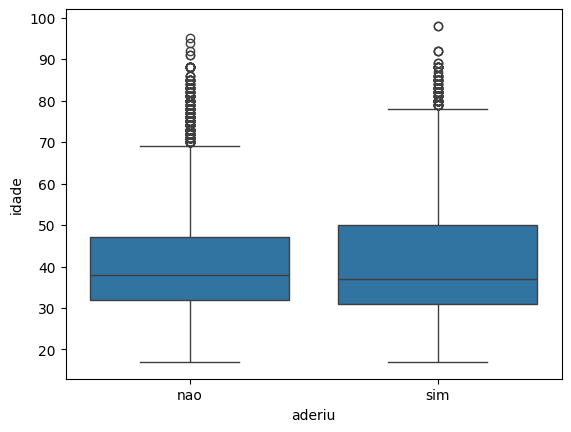

In [9]:
# Boxplot da idade por adesão

sns.boxplot(data=df, x='aderiu', y='idade')
plt.show()

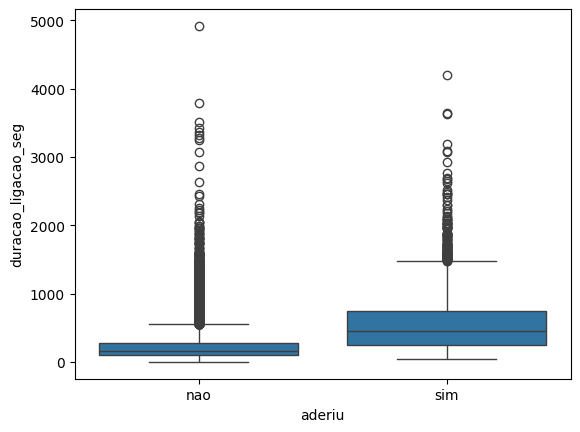

In [10]:
# Boxplot da duração da ligação por adesão

sns.boxplot(data=df, x='aderiu', y='duracao_ligacao_seg')
plt.show()

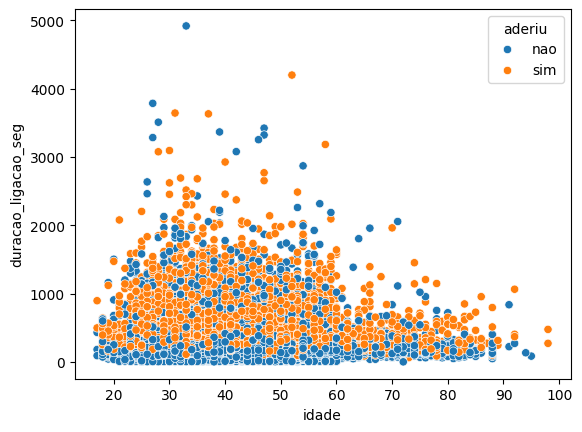

In [11]:
# Dispersão entre idade e duração da ligação

sns.scatterplot(data=df, x='idade', y='duracao_ligacao_seg', hue='aderiu')
plt.show()

**Qualidade da base:** Verificamos que não existem valores nulos na base, mas o valor "desconhecido" aparece diversas vezes em diversas categorias (como profissão, escolaridade e estado civil). Visto isso, para garantir que o modelo seja confiável e não considere padrões distorcidos, vamos ter que tratar os valores "desconhecidos".

In [12]:
# Preparação dos dados

# Removendo linhas com "desconhecido" para evitar dados "bagunçados"
print(f"Tamanho original: {df.shape}")
df_limpo = df.replace('desconhecido', pd.NA).dropna()
print(f"Tamanho após limpeza: {df_limpo.shape}")

Tamanho original: (41188, 21)
Tamanho após limpeza: (30488, 21)


In [13]:
# Definindo a variável alvo e separando os cenários
y = df_limpo['aderiu']
X_completo = df_limpo.drop(columns=['aderiu'])

# O Cenário Principal exclui atributos que só existiriam APÓS a ligação
X_principal = X_completo.drop(columns=['duracao_ligacao_seg'])

In [14]:
# Transformando categorias em números

# Isso transforma texto em colunas de 0 e 1
X_completo_encoded = pd.get_dummies(X_completo, drop_first=True)
X_principal_encoded = pd.get_dummies(X_principal, drop_first=True)

In [15]:
# Dividindo em Treino (70%) e Teste (30%) antes do escalonamento

# Cenário Principal
X_train_prin, X_test_prin, y_train, y_test = train_test_split(
    X_principal_encoded, y, test_size=0.3, stratify=y, random_state=42
)

# Cenário Completo
X_train_comp, X_test_comp, _, _ = train_test_split(
    X_completo_encoded, y, test_size=0.3, stratify=y, random_state=42
)

print(f"\nTreino (Principal): {X_train_prin.shape}, Teste: {X_test_prin.shape}")


Treino (Principal): (21341, 46), Teste: (9147, 46)


Por fim dessa etapa de preparação dos dados, separamos em 70% treino e 30% teste, onde o teste vai ser usado para medir o desempenho no final.

Aqui começamos a etapa de modelagem para os três classificadores:

In [16]:
# Modelo KNN inicial

scaler = StandardScaler()

X_train_prin_scaled = scaler.fit_transform(X_train_prin)

X_test_prin_scaled = scaler.transform(X_test_prin)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_prin_scaled, y_train)


KNeighborsClassifier()

O KNN é um modelo lazy learner, que funciona a base de distâncias para fazer sua decisão. Por isso acabamos padronizando uma mesma escala, usamos fit nos dados de treino para ele aprender os parâmetros de média e desvio e escolhemos inicialmente k=5, significando que depois dele calcular as distâncias ele vai pegar o 5 primeiros vizinhos e escolher a classe com mais votos. O k = 5 foi escolhido apenas para validarmos o modelo, ja que vamos usar validação cruzada para ver se o valor 5 é realmente o melhor valor para esse modelo.

In [17]:
# Transformando o alvo em 0 e 1
y_train_num = y_train.map({'nao': 0, 'sim': 1})
y_test_num = y_test.map({'nao': 0, 'sim': 1})

# Testando diferentes valores ímpares para k
valores_k = [3, 5, 7, 9, 11]
melhor_k = None
melhor_f1 = 0

for k in valores_k:
    knn_cv = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(knn_cv, X_train_prin_scaled, y_train_num, cv=5, scoring='f1')

    media = scores.mean()
    desvio = scores.std()

    print(f"k = {k:2d} | F1-Score médio: {media:.4f} (Desvio: {desvio:.4f})")

    if media > melhor_f1:
        melhor_f1 = media
        melhor_k = k

print(f"\nMelho valor para k = {melhor_k}.")

k =  3 | F1-Score médio: 0.3712 (Desvio: 0.0252)
k =  5 | F1-Score médio: 0.3736 (Desvio: 0.0203)
k =  7 | F1-Score médio: 0.3699 (Desvio: 0.0178)
k =  9 | F1-Score médio: 0.3645 (Desvio: 0.0204)
k = 11 | F1-Score médio: 0.3571 (Desvio: 0.0253)

Melho valor para k = 5.


Como o melhor valor realmente foi 5, seguimos para treinar o modelo final KNN com k = 5:

In [21]:
# Treinando o modelo final com o melhor hiperparâmetro (k=5)

knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train_prin_scaled, y_train_num)

# Previsões no conjunto de teste
y_pred_knn = knn_final.predict(X_test_prin_scaled)

print("\nRelatório de classificação:")
print(classification_report(y_test_num, y_pred_knn))


Relatório de classificação:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      7989
           1       0.51      0.30      0.38      1158

    accuracy                           0.88      9147
   macro avg       0.71      0.63      0.65      9147
weighted avg       0.85      0.88      0.86      9147



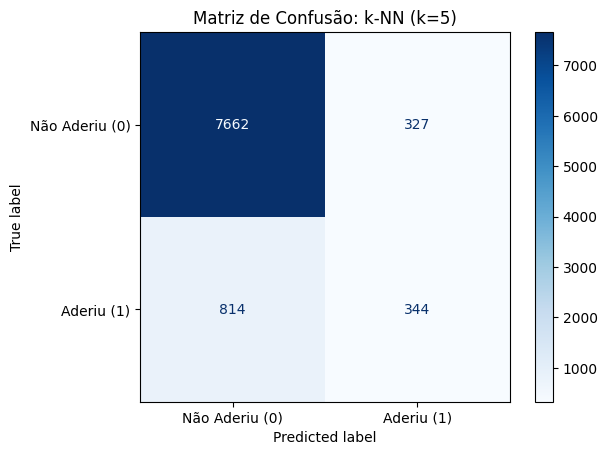

In [24]:
# Matriz de confusao knn
ConfusionMatrixDisplay.from_predictions(
    y_test_num,
    y_pred_knn,
    display_labels=['Não Aderiu (0)', 'Aderiu (1)'],
    cmap='Blues'
)
plt.title('Matriz de Confusão: k-NN (k=5)')
plt.show()

**Avalição do modelo KNN final (Cenario principal):** A acurácia do modelo ficou em 88%, porém, como comentado antes, a nossa base possui uma distribuição desigual entre os dados, onde a classe "Não Aderiu" possui 7989 registros no teste, de um total de 9147. Isso significa que se a gente chutasse "não" para todos os clientes, ja teríamos cerca de 87% de acerto, então 88% representa um ganho extremamente baixo em relação ao chute.

A classe de interesse é adesão (1), então precisamos olhar métricas específicas para observar essa classe minoritária:

-Recall: Dos 1.158 clientes que realmente aderiram ao produto (344 VP + 814 FN), o modelo só conseguiu identificar 344. Isso resulta em um recall muito baixo de apenas 30%. O modelo deixou passar 814 clientes em potencial, o que significa perda de vendas.

-Precisão: Dos 671 clientes que o modelo previu que iriam aderir (344 VP + 327 FP), 344 de fato aderiram, gerando uma precisão de 51%.

-F1-Score: Apenas 38%, denunciando a fraqueza do modelo em detectar os clientes interessados.


In [39]:
# Treinando o k-NN com os dados completos
knn_comp = KNeighborsClassifier(n_neighbors=5)
knn_comp.fit(X_train_comp_scaled, y_train_num)

# Previsão
y_pred_knn_comp = knn_comp.predict(X_test_comp_scaled)

# Métricas
print("\nRelatório de Classificação (k-NN - Cenário Completo):")
print(classification_report(y_test_num, y_pred_knn_comp))



Relatório de Classificação (k-NN - Cenário Completo):
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      7989
           1       0.57      0.34      0.42      1158

    accuracy                           0.88      9147
   macro avg       0.74      0.65      0.68      9147
weighted avg       0.87      0.88      0.87      9147



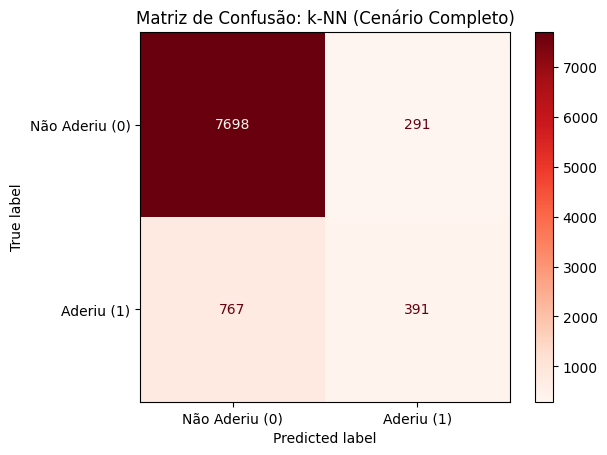

In [40]:
# Matriz de Confusão KNN Completo
ConfusionMatrixDisplay.from_predictions(
    y_test_num, y_pred_knn_comp,
    display_labels=['Não Aderiu (0)', 'Aderiu (1)'],
    cmap='Reds'
)
plt.title('Matriz de Confusão: k-NN (Cenário Completo)')
plt.show()

**Avaliação do modelo k-NN final (Cenário Completo - Com Vazamento):** A acurácia aparente do modelo se manteve em 88%. No entanto, como discutido anteriormente, a nossa base de teste possui uma distribuição desbalanceada com 7.989 registros da classe "Não Aderiu" frente a 1.158 da classe "Aderiu". Isso significa que um palpite cego na classe majoritária já garantiria cerca de 87% de acerto de forma gratuita, fazendo com que os 88% representem uma margem de melhora muito sutil em relação a uma linha de base simplista.

Avaliando especificamente a classe de interesse minoritária (Aderir = 1) com a nova matriz de confusão:

-Recall: Dos 1.158 clientes que realmente aderiram ao produto (391 VP + 767 FN), o modelo conseguiu identificar corretamente 391. Embora tenha apresentado uma leve melhora em relação ao cenário anterior, o recall ainda é baixo, situando-se em 34%. O modelo continuou deixando passar 767 clientes potenciais, resultando em perda significativa de oportunidades de negócio.

-Precisão: Dos 682 clientes que o modelo previu que iriam aderir (391 VP + 291 FP), 391 de fato confirmaram a adesão, elevando a precisão para 57%.

-F1-Score: Subiu para 42%, refletindo o leve ganho na captura de clientes, mas ainda denunciando a dificuldade do algoritmo em encontrar um equilíbrio sólido para a classe minoritária.

**Análise Crítica do Impacto do Cenário Completo no k-NN:**
A introdução da variável de duração da ligação provocou uma alteração sutil, mas perceptível, no comportamento do k-NN: o modelo tornou-se ligeiramente mais sensível (subindo o recall de 30% para 34% e reduzindo os falsos negativos). Contudo, diferentemente da Regressão Logística, o k-NN não possui coeficientes lineares interpretáveis para escancarar o vazamento de dados de forma direta; seu funcionamento puramente baseado em distâncias geométricas apenas absorveu a variável extra, ilustrando como o data leakage infla o desempenho de forma sutil e silenciosa em algoritmos baseados em vizinhança.

Segundo classificador, Naive Bayes:

In [19]:
# Comparando variantes do modelo Naive Bayes

# Testando o GaussianNB (variáveis contínuas)
gnb = GaussianNB()
scores_gnb = cross_val_score(gnb, X_train_prin_scaled, y_train_num, cv=5, scoring='f1')
print(f"GaussianNB  | F1-Score Médio: {scores_gnb.mean():.4f} (Desvio: {scores_gnb.std():.4f})")

GaussianNB  | F1-Score Médio: 0.4020 (Desvio: 0.0341)


In [20]:
# Testando o BernoulliNB (variáveis binárias)

bnb = BernoulliNB()
scores_bnb = cross_val_score(bnb, X_train_prin_scaled, y_train_num, cv=5, scoring='f1')
print(f"BernoulliNB | F1-Score Médio: {scores_bnb.mean():.4f} (Desvio: {scores_bnb.std():.4f})")

BernoulliNB | F1-Score Médio: 0.4232 (Desvio: 0.0180)


Decidimos comparar o Gaussian (com foco em variaveis continuas) e o Bernoulli (com foco em variaveis binarias) para escolhermos a variante adequada.

Não consideramos a variante CategorialNB para comparação pois decidimos anteriormente fazer o One-Hot Encoding para convertar as categorias em colunas com 0 e 1, e essa variante é projetada para lidar com categorias representadas por números inteiros. Essa transformação das categorias para 0 e 1 também prejudicou o GaussianNB ja que ele tem foco em número contínuos.

Considerando isso, a variante BernoulliNB teve um melhor desempenho ja que ela tem foco em variaveis binarias (0 e 1), mostrando um F1-Score médio de 42,32% (melhor que 40,20% do GaussainNB).

In [23]:
# Treinando o modelo Bernoulli

bnb_final = BernoulliNB()
bnb_final.fit(X_train_prin_scaled, y_train_num)

# Previsões no conjunto de teste

y_pred_bnb = bnb_final.predict(X_test_prin_scaled)

print("\nRelatório de classificação:")
print(classification_report(y_test_num, y_pred_bnb))


Relatório de classificação:
              precision    recall  f1-score   support

           0       0.93      0.84      0.88      7989
           1       0.34      0.57      0.42      1158

    accuracy                           0.80      9147
   macro avg       0.63      0.70      0.65      9147
weighted avg       0.86      0.80      0.82      9147



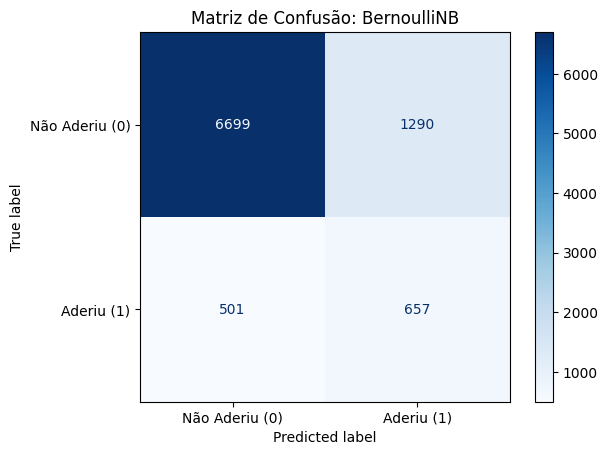

In [25]:
# Matriz de confusao naives bayes bernoulli
ConfusionMatrixDisplay.from_predictions(
    y_test_num,
    y_pred_bnb,
    display_labels=['Não Aderiu (0)', 'Aderiu (1)'],
    cmap='Blues'
)
plt.title('Matriz de Confusão: BernoulliNB')
plt.show()

**Avalição do modelo Naive Bayes (Bernoulli) final (Cenario pricipal):** A acurácia do modelo ficou em 80%, e apesar de ser 8 pontos a menos que o KNN, comentamos que devemos olhar para as métricas específicas para observar a classe de interesse (adesão = 1), que neste caso tiveram um comportamento muito diferente do KNN:

-Recall: Dos 1.158 clientes que realmente aderiram ao produto (657 VP + 501 FN), o modelo conseguiu identificar 657. Isso resulta em um recall de 57%. Comparando com o KNN (30%), conseguimos um recall quase duas vezes mais eficiente em identificar clientes interessados.

-Precisão: Dos 1947 clientes que o modelo previu que iriam aderir (657 VP + 1290 FP), 657 de fato aderiram, gerando uma precisão de apenas 34%, devido ao grande número de falsos positivos.

-F1-Score: Apenas 42%, sendo um pouco melhor que os 38% do KNN mas ainda sim denunciando a fraqueza do modelo em detectar os clientes interessados.

Em comparação ao KNN, se a estratégia de negócio do banco considerar que ligar e ouvir um "não" (falso positivo) custa muito menos do que deixar de fechar um contrato (falso negativo), o modelo BernoulliNB é superior ao KNN, pois reduz muito os clientes interessados que passam batido.


In [41]:
# Treinando o BernoulliNB com os dados completos
bnb_comp = BernoulliNB()
bnb_comp.fit(X_train_comp_scaled, y_train_num)

# Previsão
y_pred_bnb_comp = bnb_comp.predict(X_test_comp_scaled)

# Métricas
print("\nRelatório de Classificação (BernoulliNB - Cenário Completo):")
print(classification_report(y_test_num, y_pred_bnb_comp))


Relatório de Classificação (BernoulliNB - Cenário Completo):
              precision    recall  f1-score   support

           0       0.93      0.85      0.89      7989
           1       0.37      0.59      0.45      1158

    accuracy                           0.82      9147
   macro avg       0.65      0.72      0.67      9147
weighted avg       0.86      0.82      0.84      9147



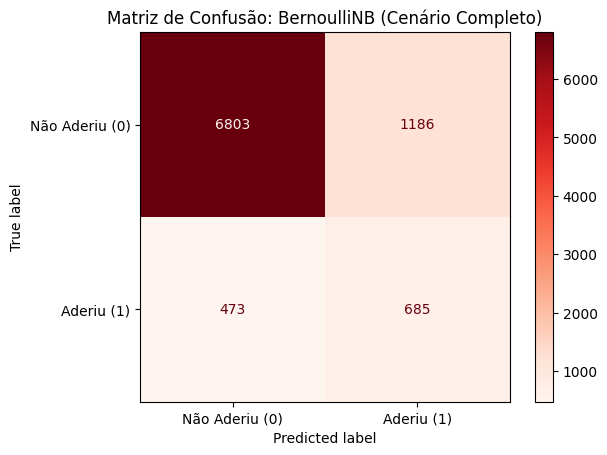

In [42]:
# Matriz de Confusão completa naive bayes
ConfusionMatrixDisplay.from_predictions(
    y_test_num, y_pred_bnb_comp,
    display_labels=['Não Aderiu (0)', 'Aderiu (1)'],
    cmap='Reds'
)
plt.title('Matriz de Confusão: BernoulliNB (Cenário Completo)')
plt.show()

**Avaliação do modelo Naive Bayes (Bernoulli) final (Cenário Completo - Com Vazamento):**

A acurácia do modelo subiu para 82% (2 pontos a mais em relação aos 80% do cenário principal). Como reforçado nas análises anteriores, a acurácia global mascara o desequilíbrio da base, tornando essencial olhar para as métricas específicas da classe de interesse minoritária (adesão = 1), que refletiram o impacto do vazamento de dados:

-Recall: Dos 1.158 clientes que realmente aderiram ao produto (685 VP + 473 FN), o modelo conseguiu identificar corretamente 685. Isso resultou em um recall de 59% (uma leve alta comparada aos 57% do cenário principal). O modelo manteve sua característica de alta sensibilidade, capturando mais clientes interessados do que os demais algoritmos.

-Precisão: Dos 1.871 clientes que o modelo previu que iriam aderir (685 VP + 1.186 FP), 685 de fato aderiram, gerando uma precisão de 37% (um pequeno acréscimo frente aos 34% anteriores), ainda penalizada pela alta taxa de falsos positivos inerente ao perfil agressivo do classificador.

-F1-Score: Subiu para 45% (contra 42% do cenário principal), refletindo o ligeiro ganho global proporcionado pela inclusão da variável de duração, mas mantendo a restrição quanto à margem de falsos alarmes.

**Análise Crítica do Impacto do Cenário Completo no Naive Bayes:**
A introdução do atributo de duração da ligação no Cenário Completo elevou discretamente tanto o recall quanto a precisão do BernoulliNB, inflando artificialmente o F1-Score para 45%. Embora o Naive Bayes mantenha sua vantagem estrutural de ser um modelo rápido e puramente probabilístico baseado em contagens e densidades, a contaminação da base com informações do futuro (vazamento de dados) distorce suas probabilidades a posteriori, fazendo com que o algoritmo aproveite o viés temporal para superestimar o sucesso das chamadas sem que isso represente um aprendizado genuíno do perfil do cliente.

Terceiro classificador, Regressão Logistica:

In [30]:
# Validacao do Parametro C

# Grade de valores para o parametro C
grade_lr = {'C': [0.01, 0.1, 1.0, 10.0, 100.0]}

# Modelo regressao logistica
lr_base = LogisticRegression(max_iter=1000)

busca_lr = GridSearchCV(lr_base, grade_lr, cv=5, scoring='f1', n_jobs=-1)

busca_lr.fit(X_train_prin_scaled, y_train_num)

print(f"Melhor parâmetro encontrado: {busca_lr.best_params_}")
print(f"F1-Score Médio (Treino): {busca_lr.best_score_:.4f}")

Melhor parâmetro encontrado: {'C': 1.0}
F1-Score Médio (Treino): 0.3641


Para definir o parâmetro de regularização C, utilizamos o método de validação cruzada no conjunto de treino. Testamos uma grade de valores (0.01 a 100)e descobrimos que o valor C = 1.0 maximizou o desempenho médio do modelo, com F1-Score Médio = 36,41%.

In [31]:
# Modelo regressao logistica com o C vencedor
lr_final = LogisticRegression(C=1.0, max_iter=1000)
lr_final.fit(X_train_prin_scaled, y_train_num)

LogisticRegression(max_iter=1000)

In [33]:
# 5 maiores coeficientes
coeficientes = lr_final.coef_[0]
nomes_features = X_train_prin.columns

df_coef = pd.DataFrame({'Atributo': nomes_features, 'Peso (b)': coeficientes})
df_coef['Razão de Chances (e^b)'] = np.exp(df_coef['Peso (b)'])
df_coef['Magnitude'] = df_coef['Peso (b)'].abs()

top_5_coef = df_coef.sort_values(by='Magnitude', ascending=False).head(5)

print("\nOs 5 atributos de maior impacto na decisão:")
print(top_5_coef[['Atributo', 'Peso (b)', 'Razão de Chances (e^b)']])


Os 5 atributos de maior impacto na decisão:
                      Atributo  Peso (b)  Razão de Chances (e^b)
4        taxa_variacao_emprego -2.328210                0.097470
5     indice_precos_consumidor  1.290464                3.634474
8            numero_empregados  0.676685                1.967345
30  meio_contato_telefone_fixo -0.379128                0.684458
2    dias_desde_ultimo_contato -0.260160                0.770928


Analisando os 5 atributos de maior magnitude, a avaliação segue a regra de que o peso negativo leva para não aderiu, enquanto o peso positivo leva para aderiu:

-Taxa de variação de emprego (b = -2,32): É o fator de maior peso absoluto no modelo e leva o cliente fortemente para a não adesão. O aumento de um desvio padrão neste atributo multiplica a chance de adesão por apenas 0,09 (reduzindo a probabilidade drasticamente).

-Índice de Preços ao Consumidor (b = 1,29): É o fator de maior peso positivo. Subir um desvio padrão neste índice multiplica a chance de o cliente aderir por 3,63 vezes.

-Número de Empregados (b = 0,67): Atua a favor da adesão. O aumento de um desvio padrão multiplica a chance de fechamento do negócio por 1,96, quase dobrando a probabilidade de sucesso.

-Meio de Contato (Telefone Fixo) (b = -0,37): Puxa a probabilidade para baixo. Usar o telefone fixo como via de contato multiplica a chance de sucesso por apenas 0,68 (desfavorecendo a adesão).

-Dias Desde o Último Contato $b = -0,26): Também leva para a recusa. O aumento desse tempo multiplica a chance de adesão por 0,77.

In [34]:
# Previsões no conjunto de teste
y_pred_lr = lr_final.predict(X_test_prin_scaled)

print("\nRelatório de Classificação:")
print(classification_report(y_test_num, y_pred_lr))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7989
           1       0.65      0.25      0.36      1158

    accuracy                           0.89      9147
   macro avg       0.77      0.62      0.65      9147
weighted avg       0.87      0.89      0.87      9147



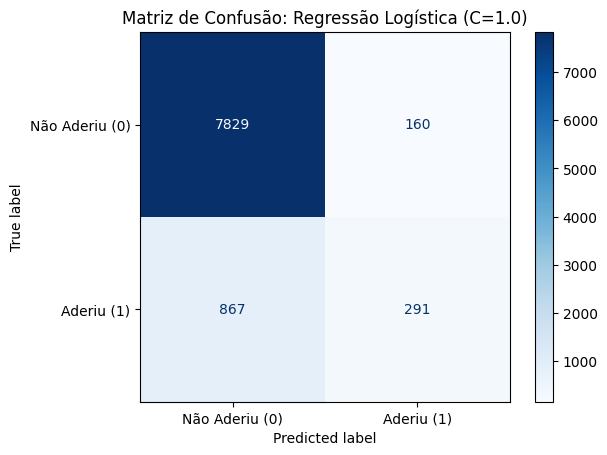

In [35]:
# Matriz de Confusão
ConfusionMatrixDisplay.from_predictions(
    y_test_num,
    y_pred_lr,
    display_labels=['Não Aderiu (0)', 'Aderiu (1)'],
    cmap='Blues'
)
plt.title('Matriz de Confusão: Regressão Logística (C=1.0)')
plt.show()

**Avalição do modelo Regressão Logística final:** A acurácia do modelo ficou em 89%, e apesar de ser a maior acurácia encontrada entre os modelos, ainda devemos olhar para as métricas específicas para observar a classe de interesse (adesão = 1):

-Recall: Dos 1.158 clientes que realmente aderiram ao produto (291 VP + 867 FN), o modelo cobriu apenas 291. Isso resulta no pior recall entre os modelos, de apenas 25%. O modelo ignorou 867 potenciais compradores.

-Precisão: Dos 451 clientes que o modelo previu que iriam aderir (291 VP + 160 FP), 291 de fato aderiram, gerando a maior precisão entre os modelos, de 65%. O modelo é cirúrgico e indicou apenas 160 falsos positivos.

-F1-Score: O desequílibrio fez o F1-Score chegar em apenas 36%, tabmém denunciando a fraqueza do modelo em detectar os clientes interessados.

A escolha do modelo vencedor depende estritamente da regra de negócio do banco. Se a prioridade for poupar recursos do call-center ("acusar errado é caro"), a Regressão Logística é imbatível. Porém, se a prioridade for maximizar a conversão de vendas onde "deixar passar é caro", o Naive Bayes se mostrou muito superior.


Considerando o cenário completo:

In [36]:
# Padronizando os dados do Cenário Completo (X_train_comp e X_test_comp)
scaler_comp = StandardScaler()

X_train_comp_scaled_matrix = scaler_comp.fit_transform(X_train_comp)
X_test_comp_scaled_matrix = scaler_comp.transform(X_test_comp)

# DataFrame para podermos ler os nomes das colunas
X_train_comp_scaled = pd.DataFrame(X_train_comp_scaled_matrix, columns=X_train_comp.columns)
X_test_comp_scaled = pd.DataFrame(X_test_comp_scaled_matrix, columns=X_test_comp.columns)

# 2. Treinando a Regressão Logística no Cenário Completo
lr_comp = LogisticRegression(C=1.0, max_iter=1000)
lr_comp.fit(X_train_comp_scaled, y_train_num)

# 3. Fazendo previsões e gerando as métricas
y_pred_comp = lr_comp.predict(X_test_comp_scaled)

print("\nRelatório de Classificação (Regressão Logística - Cenário Completo):")
print(classification_report(y_test_num, y_pred_comp))



Relatório de Classificação (Regressão Logística - Cenário Completo):
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7989
           1       0.65      0.45      0.53      1158

    accuracy                           0.90      9147
   macro avg       0.79      0.71      0.74      9147
weighted avg       0.89      0.90      0.89      9147



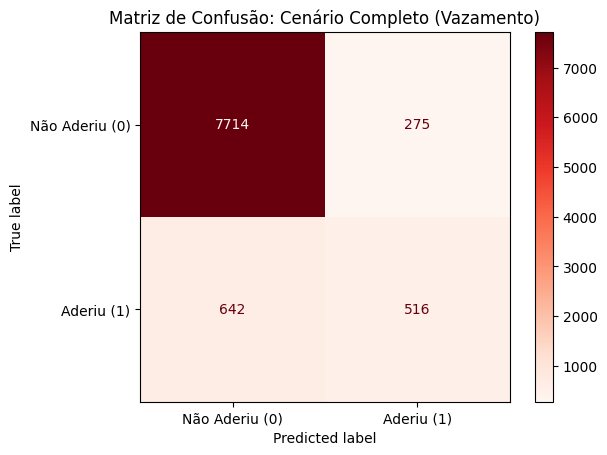

In [37]:
# 4. Matriz de Confusão
ConfusionMatrixDisplay.from_predictions(
    y_test_num,
    y_pred_comp,
    display_labels=['Não Aderiu (0)', 'Aderiu (1)'],
    cmap='Reds'
)
plt.title('Matriz de Confusão: Cenário Completo (Vazamento)')
plt.show()

In [38]:
# Extraindo os pesos do modelo treinado no Cenário Completo
coeficientes_comp = lr_comp.coef_[0]
nomes_features_comp = X_train_comp.columns

df_coef_comp = pd.DataFrame({'Atributo': nomes_features_comp, 'Peso (b)': coeficientes_comp})
df_coef_comp['Magnitude'] = df_coef_comp['Peso (b)'].abs()

top_5_comp = df_coef_comp.sort_values(by='Magnitude', ascending=False).head(5)

print("5 Coeficientes (Cenário Completo)")
print(top_5_comp[['Atributo', 'Peso (b)']])

5 Coeficientes (Cenário Completo)
                      Atributo  Peso (b)
5        taxa_variacao_emprego -2.489521
6     indice_precos_consumidor  1.239700
1          duracao_ligacao_seg  1.209592
9            numero_empregados  0.497169
31  meio_contato_telefone_fixo -0.314725


**Avaliação do modelo Regressão Logística final (Cenário Completo - Com Vazamento): **

A acurácia global do modelo subiu para 90% (comparada aos 89% do cenário principal). Novamente, ignorando a armadilha da acurácia e focando na classe minoritária de interesse (adesão = 1), as métricas refletiram uma melhora aparente provocada pela contaminação dos dados:

-Recall: Dos 1.158 clientes que realmente aderiram ao produto (516 VP + 642 FN), o modelo conseguiu identificar corretamente 516. Isso resultou em um recall de 45% (uma melhora expressiva em relação aos 25% do cenário principal), capturando quase o dobro de clientes interessados.

-Precisão: Dos 791 clientes que o modelo previu que iriam aderir (516 VP + 275 FP), 516 de fato confirmaram a adesão, mantendo uma precisão sólida de 65%, idêntica à do cenário anterior e conservando o controle rigoroso sobre os falsos positivos.

-F1-Score: Subiu para 53% (contra 36% do cenário principal), refletindo o ganho gerado pela variável introduzida.

**Análise Crítica e a Prova do Vazamento de Dados (Data Leakage):** A inclusão da variável duracao_ligacao_seg provocou uma inflação artificial no desempenho da Regressão Logística. A grande vantagem estrutural deste modelo — ser "interpretável de verdade" através de seus pesos — permitiu desmascarar o problema: ao extrairmos os coeficientes, a duração da ligação apareceu de forma destacada no Top 3 de maior impacto $b = 1,209). Como a duração de uma chamada comercial só é conhecida após o seu término (ou seja, quando o resultado já está decidido), fornecê-la ao modelo constitui uma informação privilegiada do futuro. Isso prova que o ganho de performance não veio de um aprendizado legítimo do perfil do cliente, mas sim de um vício metodológico que torna o modelo inaplicável para predições reais em produção.

In [43]:
print("Validação Cruzada Consolidada (Cenário Principal)")

modelos = {
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes (Bernoulli)': BernoulliNB(),
    'Regressão Logística (C=1.0)': LogisticRegression(C=1.0, max_iter=1000)
}

tabela_resultados = []

# Executando a validação cruzada para cada modelo
for nome, modelo in modelos.items():

    scores = cross_val_score(modelo, X_train_prin_scaled, y_train_num, cv=5, scoring='f1')

    tabela_resultados.append({
        'Modelo': nome,
        'Métrica Média (F1)': f"{scores.mean():.4f}",
        'Desvio-Padrão (Std)': f"{scores.std():.4f}",
        'Scores por Dobra': [f"{s:.4f}" for s in scores]
    })


df_comparativo = pd.DataFrame(tabela_resultados)
print("\nTabela Comparativa de Validação Cruzada:")
display(df_comparativo)

Validação Cruzada Consolidada (Cenário Principal)

Tabela Comparativa de Validação Cruzada:


,Modelo,Métrica Média (F1),Desvio-Padrão (Std),Scores por Dobra
0,k-NN (k=5),0.3736,0.0203,"[0.3667, 0.3371, 0.3830, 0.3924, 0.3888]"
1,Naive Bayes (Bernoulli),0.4232,0.0180,"[0.4340, 0.3879, 0.4359, 0.4254, 0.4325]"
2,Regressão Logística (C=1.0),0.3641,0.0372,"[0.3228, 0.3238, 0.4216, 0.3762, 0.3760]"
